In [19]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator
from scipy.interpolate import griddata


# ============================================================
# Paths
# ============================================================

# test 하위 폴더가 아니라 validation 결과가 있는 rf_grid 자체
ROOT_DIR = Path(
    "/shared/data_zfs/blue2959/ND_Aligner/experiments/v2.0/rf_grid_conv1d"
)

OUTPUT_PDF = ROOT_DIR / "rf_grid_validation_heatmap.pdf"
OUTPUT_PNG = ROOT_DIR / "rf_grid_validation_heatmap.png"

DIR_PATTERN = re.compile(
    r"v2\.0_vctk_conv-RF=(\d+)\+text-RF=(\d+)"
)

In [20]:
# ============================================================
# Load each experiment's best validation checkpoint
# ============================================================

records = []

for exp_dir in sorted(ROOT_DIR.iterdir()):
    if not exp_dir.is_dir():
        continue

    match = DIR_PATTERN.fullmatch(exp_dir.name)
    if match is None:
        continue

    conv_rf = int(match.group(1))
    text_rf = int(match.group(2))

    csv_path = exp_dir / "eval_metrics.csv"

    if not csv_path.exists():
        print(f"[SKIP] Missing: {csv_path}")
        continue

    df = pd.read_csv(csv_path)

    required_columns = {
        "step",
        "word_boundary_error",
        "p_word_10ms",
        "p_word_25ms",
        "p_word_50ms",
        "p_word_100ms",
    }
    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        print(
            f"[SKIP] Missing columns in {csv_path}: "
            + f"{sorted(missing_columns)}"
        )
        continue

    df = (
        df[
            [
                "step",
                "word_boundary_error",
                "p_word_10ms",
                "p_word_25ms",
                "p_word_50ms",
                "p_word_100ms",
            ]
        ]
        .dropna(
            subset=[
                "step",
                "word_boundary_error",
                "p_word_10ms",
                "p_word_25ms",
                "p_word_50ms",
                "p_word_100ms",
            ]
        )
        .copy()
    )

    if df.empty:
        print(f"[SKIP] No valid rows: {csv_path}")
        continue

    # 해당 RF 설정에서 validation WBE가 가장 낮은 checkpoint 선택
    best_idx = df["word_boundary_error"].idxmin()
    best_row = df.loc[best_idx]

    records.append(
        {
            "conv_rf": conv_rf,
            "text_rf": text_rf,
            "best_step": int(best_row["step"]),
            "wbe_ms": (
                float(best_row["word_boundary_error"])
                * 1000.0
            ),
            # WBE minimum checkpoint에서의 threshold metrics
            "p10": float(best_row["p_word_10ms"]),
            "p25": float(best_row["p_word_25ms"]),
            "p50": float(best_row["p_word_50ms"]),
            "p100": float(best_row["p_word_100ms"]),
        }
    )

    print(
        f"[LOAD] conv-RF={conv_rf}, text-RF={text_rf} | "
        + f"step={int(best_row['step'])} | "
        + f"WBE={float(best_row['word_boundary_error']) * 1000.0:.3f} ms | "
        + f"P10={float(best_row['p_word_10ms']):.3f}% | "
        + f"P25={float(best_row['p_word_25ms']):.3f}% | "
        + f"P50={float(best_row['p_word_50ms']):.3f}% | "
        + f"P100={float(best_row['p_word_100ms']):.3f}%"
    )


if not records:
    raise RuntimeError(
        "No valid validation experiment results found."
    )

[LOAD] conv-RF=1, text-RF=1 | step=162500 | WBE=24.681 ms | P10=37.372% | P25=68.627% | P50=88.959% | P100=96.709%
[LOAD] conv-RF=1, text-RF=3 | step=148000 | WBE=23.455 ms | P10=36.625% | P25=67.367% | P50=88.142% | P100=98.063%
[LOAD] conv-RF=1, text-RF=5 | step=100000 | WBE=22.039 ms | P10=36.695% | P25=70.705% | P50=91.060% | P100=98.553%
[LOAD] conv-RF=1, text-RF=7 | step=94500 | WBE=27.329 ms | P10=30.439% | P25=62.045% | P50=84.524% | P100=97.736%
[LOAD] conv-RF=3, text-RF=1 | step=41500 | WBE=23.306 ms | P10=38.539% | P25=68.301% | P50=88.165% | P100=97.876%
[LOAD] conv-RF=3, text-RF=3 | step=41500 | WBE=23.799 ms | P10=34.921% | P25=68.511% | P50=88.002% | P100=97.736%
[LOAD] conv-RF=5, text-RF=1 | step=132000 | WBE=21.809 ms | P10=41.106% | P25=70.752% | P50=88.725% | P100=98.413%
[LOAD] conv-RF=5, text-RF=3 | step=119500 | WBE=22.626 ms | P10=38.399% | P25=70.495% | P50=87.979% | P100=98.086%
[LOAD] conv-RF=5, text-RF=5 | step=34000 | WBE=28.260 ms | P10=23.973% | P25=60.131

In [21]:
result_df = pd.DataFrame(records)

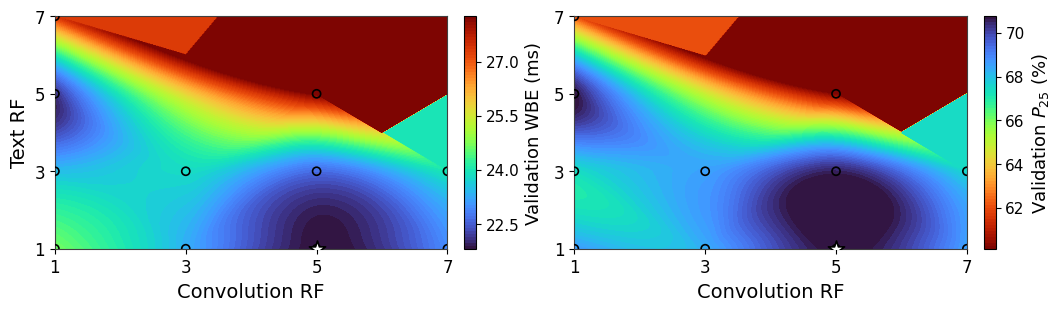


Saved PDF: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.0/rf_grid_conv1d/rf_grid_validation_heatmap.pdf
Saved PNG: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.0/rf_grid_conv1d/rf_grid_validation_heatmap.png


In [22]:
conv_rfs = sorted(
    result_df["conv_rf"].unique()
)

text_rfs = sorted(
    result_df["text_rf"].unique()
)


# ============================================================
# Interpolation
# ============================================================

def interpolate_metric_surface(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    *,
    resolution: int = 300,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Sparse RF-grid observations를 dense surface로 보간합니다.

    cubic interpolation이 정의되지 않는 영역은
    linear -> nearest 순서로 보완합니다.
    """
    dense_x = np.linspace(
        x.min(),
        x.max(),
        resolution,
    )
    dense_y = np.linspace(
        y.min(),
        y.max(),
        resolution,
    )

    grid_x, grid_y = np.meshgrid(
        dense_x,
        dense_y,
    )

    grid_z_cubic = griddata(
        points=(x, y),
        values=z,
        xi=(grid_x, grid_y),
        method="cubic",
    )

    grid_z_linear = griddata(
        points=(x, y),
        values=z,
        xi=(grid_x, grid_y),
        method="linear",
    )

    grid_z_nearest = griddata(
        points=(x, y),
        values=z,
        xi=(grid_x, grid_y),
        method="nearest",
    )

    grid_z = np.where(
        np.isnan(grid_z_cubic),
        grid_z_linear,
        grid_z_cubic,
    )

    grid_z = np.where(
        np.isnan(grid_z),
        grid_z_nearest,
        grid_z,
    )

    # Cubic interpolation overshoot 방지
    grid_z = np.clip(
        grid_z,
        np.nanmin(z),
        np.nanmax(z),
    )

    return grid_x, grid_y, grid_z


# ============================================================
# Heatmap helper
# ============================================================

def plot_metric_heatmap(
    ax: plt.Axes,
    *,
    metric_column: str,
    colorbar_label: str,
    cmap: str,
    optimum: str,
    no_xlabel=False,
) -> None:
    x = result_df["conv_rf"].to_numpy(
        dtype=float
    )
    y = result_df["text_rf"].to_numpy(
        dtype=float
    )
    z = result_df[metric_column].to_numpy(
        dtype=float
    )

    grid_x, grid_y, grid_z = (
        interpolate_metric_surface(
            x,
            y,
            z,
            resolution=300,
        )
    )

    levels = np.linspace(
        np.nanmin(z),
        np.nanmax(z),
        80,
    )

    contour = ax.contourf(
        grid_x,
        grid_y,
        grid_z,
        levels=levels,
        cmap=cmap,
        extend="neither",
    )

    # 실제 평가한 RF 조합
    ax.scatter(
        x,
        y,
        s=34,
        marker="o",
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )

    # 실제 관측값 중 최적 RF 조합 표시
    if optimum == "min":
        best_idx = int(np.nanargmin(z))
    elif optimum == "max":
        best_idx = int(np.nanargmax(z))
    else:
        raise ValueError(
            "optimum must be either 'min' or 'max'."
        )

    ax.scatter(
        x[best_idx],
        y[best_idx],
        s=150,
        marker="*",
        facecolors="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=7,
    )

    ax.set_xlabel(
        "Convolution RF",
        fontsize=14,
    )
    if not no_xlabel:
        ax.set_ylabel(
            "Text RF",
            fontsize=14,
        )

    ax.set_xticks(conv_rfs)
    ax.set_yticks(text_rfs)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=12,
    )

    ax.set_xlim(
        min(conv_rfs),
        max(conv_rfs),
    )
    ax.set_ylim(
        min(text_rfs),
        max(text_rfs),
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("0.25")

    colorbar = fig.colorbar(
        contour,
        ax=ax,
        fraction=0.046,
        pad=0.03,
    )

    colorbar.set_label(
        colorbar_label,
        fontsize=13,
    )

    colorbar.ax.tick_params(
        labelsize=11,
    )

    colorbar.locator = MaxNLocator(
        nbins=6
    )
    colorbar.update_ticks()


# ============================================================
# Plot
# ============================================================

fig, (ax_wbe, ax_p25) = plt.subplots(
    1,
    2,
    figsize=(10.5, 3.0),
    constrained_layout=True,
)


# 왼쪽: validation WBE
plot_metric_heatmap(
    ax_wbe,
    metric_column="wbe_ms",
    colorbar_label="Validation WBE (ms)",
    cmap="turbo",
    optimum="min",
)


# 오른쪽: 같은 checkpoint에서의 validation P25
plot_metric_heatmap(
    ax_p25,
    metric_column="p25",
    colorbar_label=r"Validation $P_{25}$ (%)",
    cmap="turbo_r",
    optimum="max",
    no_xlabel=True,
)


# ============================================================
# Save
# ============================================================

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print()
print(f"Saved PDF: {OUTPUT_PDF.resolve()}")
print(f"Saved PNG: {OUTPUT_PNG.resolve()}")

In [23]:
fig.savefig(OUTPUT_PDF, bbox_inches="tight")
fig.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved PDF: {OUTPUT_PDF}")
print(f"Saved PNG: {OUTPUT_PNG}")

Saved PDF: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.0/rf_grid_conv1d/rf_grid_validation_heatmap.pdf
Saved PNG: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.0/rf_grid_conv1d/rf_grid_validation_heatmap.png


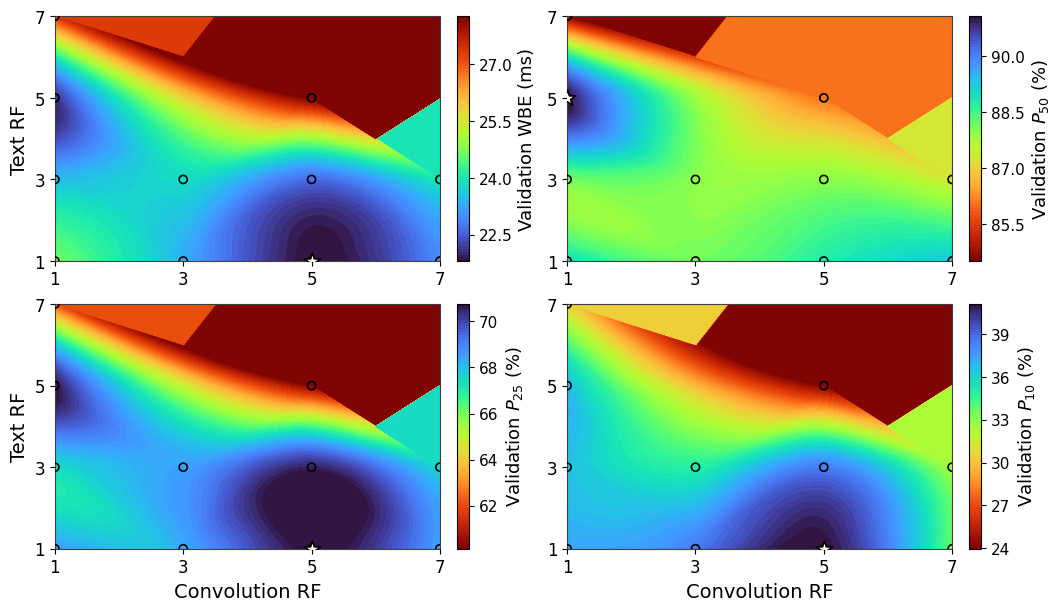


Saved PDF: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.0/rf_grid_conv1d/rf_grid_validation_heatmap.pdf
Saved PNG: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.0/rf_grid_conv1d/rf_grid_validation_heatmap.png


In [24]:
# ============================================================
# Heatmap helper
# ============================================================

def plot_metric_heatmap(
    ax: plt.Axes,
    *,
    metric_column: str,
    colorbar_label: str,
    cmap: str,
    optimum: str,
    show_xlabel: bool = True,
    show_ylabel: bool = True,
) -> None:
    x = result_df["conv_rf"].to_numpy(
        dtype=float
    )
    y = result_df["text_rf"].to_numpy(
        dtype=float
    )
    z = result_df[metric_column].to_numpy(
        dtype=float
    )

    grid_x, grid_y, grid_z = (
        interpolate_metric_surface(
            x,
            y,
            z,
            resolution=300,
        )
    )

    levels = np.linspace(
        np.nanmin(z),
        np.nanmax(z),
        80,
    )

    contour = ax.contourf(
        grid_x,
        grid_y,
        grid_z,
        levels=levels,
        cmap=cmap,
        extend="neither",
    )

    # 실제 평가한 RF 조합
    ax.scatter(
        x,
        y,
        s=34,
        marker="o",
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )

    # 실제 관측값 중 최적 RF 조합 표시
    if optimum == "min":
        best_idx = int(np.nanargmin(z))
    elif optimum == "max":
        best_idx = int(np.nanargmax(z))
    else:
        raise ValueError(
            "optimum must be either 'min' or 'max'."
        )

    ax.scatter(
        x[best_idx],
        y[best_idx],
        s=150,
        marker="*",
        facecolors="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=7,
    )

    if show_xlabel:
        ax.set_xlabel(
            "Convolution RF",
            fontsize=14,
        )
    else:
        ax.set_xlabel("")

    if show_ylabel:
        ax.set_ylabel(
            "Text RF",
            fontsize=14,
        )
    else:
        ax.set_ylabel("")

    ax.set_xticks(conv_rfs)
    ax.set_yticks(text_rfs)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=12,
    )

    ax.set_xlim(
        min(conv_rfs),
        max(conv_rfs),
    )
    ax.set_ylim(
        min(text_rfs),
        max(text_rfs),
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("0.25")

    colorbar = ax.figure.colorbar(
        contour,
        ax=ax,
        fraction=0.046,
        pad=0.03,
    )

    colorbar.set_label(
        colorbar_label,
        fontsize=13,
    )

    colorbar.ax.tick_params(
        labelsize=11,
    )

    colorbar.locator = MaxNLocator(
        nbins=6
    )
    colorbar.update_ticks()

# ============================================================
# Plot
#
# Layout:
# ┌───────────────┬───────────────┐
# │      WBE      │      P50      │
# ├───────────────┼───────────────┤
# │      P25      │      P10      │
# └───────────────┴───────────────┘
# ============================================================

fig = plt.figure(
    figsize=(10.5, 6.0),
    constrained_layout=True,
)

grid_spec = fig.add_gridspec(
    nrows=2,
    ncols=2,
)

ax_wbe = fig.add_subplot(grid_spec[0, 0])
ax_p50 = fig.add_subplot(grid_spec[0, 1])
ax_p25 = fig.add_subplot(grid_spec[1, 0])
ax_p10 = fig.add_subplot(grid_spec[1, 1])


# ============================================================
# Top-left: WBE
# ============================================================

plot_metric_heatmap(
    ax_wbe,
    metric_column="wbe_ms",
    colorbar_label="Validation WBE (ms)",
    cmap="turbo",
    optimum="min",
    show_xlabel=False,
    show_ylabel=True,
)


# ============================================================
# Top-right: P50
# ============================================================

plot_metric_heatmap(
    ax_p50,
    metric_column="p50",
    colorbar_label=r"Validation $P_{50}$ (%)",
    cmap="turbo_r",
    optimum="max",
    show_xlabel=False,
    show_ylabel=False,
)


# ============================================================
# Bottom-left: P25
# ============================================================

plot_metric_heatmap(
    ax_p25,
    metric_column="p25",
    colorbar_label=r"Validation $P_{25}$ (%)",
    cmap="turbo_r",
    optimum="max",
    show_xlabel=True,
    show_ylabel=True,
)


# ============================================================
# Bottom-right: P10
# ============================================================

plot_metric_heatmap(
    ax_p10,
    metric_column="p10",
    colorbar_label=r"Validation $P_{10}$ (%)",
    cmap="turbo_r",
    optimum="max",
    show_xlabel=True,
    show_ylabel=False,
)


# ============================================================
# Save
# ============================================================

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print()
print(f"Saved PDF: {OUTPUT_PDF.resolve()}")
print(f"Saved PNG: {OUTPUT_PNG.resolve()}")